### 1D monte carlo code for variance estimation

##### Antithetic variables and regression methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
class Material:
  """
  A material with cross sections.
  """
  def __init__(self, s: float, a: float, f: float, nu: float):
    self.sigS = s
    self.sigA = a
    self.sigF = f
    self.sigNu = nu
    self.sigC = self.sigA - self.sigF
    self.sigT = s+a
    self.collV = np.array([self.sigS, self.sigC, self.sigF])/self.sigT
    self.cdf = np.cumsum(self.collV)
    if self.sigF > 0:
      self.fissile = True
    else:
      self.fissile = False
  def get_collision_type(self, xi):
    """0=scatter, 1=capture, 2=fission"""
    return int(np.searchsorted(self.cdf, xi, side='right'))


class ZPlane:
  def __init__(self, z0: float):
    self.z0 = z0

  def dist(self, z: float, wZ: float, **kwargs):
    return (self.z0 - z)/wZ

class Element:
  """
  A 1D element.
  """
  def __init__(self, material: Material, dz: float):
    self.material = material
    self.dz = dz
    self._eid = None
    self._flux = 0.0
    self._surfs: list[ZPlane] = []

  @property 
  def fissile(self):
    return self.material.fissile

  @property
  def eid(self):
    return self._eid

  @property
  def flux(self):
    return self._flux
  
  @property 
  def sigT(self):
    return self.material.sigT

  def inside(self, z: float) -> bool:
    return (z>=self._left) & (z<=self._right)
    
  def add_flux_score(self, w: float, l: float, nbank: float):
    self._flux += w*l/nbank/self.vol

  def set_eid(self, eid):
    self._eid = eid

  def set_surfs(self, left: float, right: float):
    self._right = right
    self._left = left
    area = 1.0
    self.vol = (right-left)*area
    self._surfs = [ZPlane(right), ZPlane(left)]
  
  def get_surf_crossing(self, wZ: float, z: float) -> tuple[float, float]:
    """
    Returns distance to surface and surface z value
    """
    sur = None
    for this in self._surfs:
      s = this.dist(z=z, wZ=wZ)
      
      # Discard behind us
      if s < 0:
        continue
      
      # Take first one
      if sur is None:
        sur = this
        dMin = s
      
      # Compare and take min
      elif s < dMin:
        sur = this
        dMin = s
    return dMin, sur.z0

class Mesh1D:
  """
  A mesh consisting of elements arranged in an adjacent fashion.
  """
  def __init__(self, elements: list[Element], left: str, right: str):
    self.elements: list[Element] = elements
    for idx, this in enumerate(elements):
      this.set_eid(eid=idx)
    self.left = left
    self.right = right
    self.dzList = [this.dz for this in self.elements]
    self.L = sum(self.dzList)

    self.boundaryList = [0.0]
    self.leftList = [] # rightside boundaries values
    self.rightList = [] # leftside boundaries values
    # List of  boundary values
    for this in self.dzList:
      self.boundaryList.append(self.boundaryList[-1] + this)
    self.boundaryList = np.array(self.boundaryList)
    self.leftList = np.array(self.boundaryList[0:-1])
    self.rightList = np.array(self.boundaryList[1:])
    for idx, this in enumerate(elements):
      this.set_surfs(left=self.leftList[idx], right=self.rightList[idx])

    self.zMin = self.boundaryList[0]
    self.zMax = self.boundaryList[-1]

    # Fission matrix
    nele = len(self.elements)
    self.fma = np.zeros((nele,nele))

  def _where_am_i(self, z: float) -> Element:
    """
    Put in z and return where (element id) what element we are inside of
    """
    if z > self.zMax:
      return -1
    if z < self.zMin:
      return -1
    for idx, this in enumerate(self.boundaryList[0:-1]):
      if (z > self.boundaryList[idx]) & (z <= self.boundaryList[idx+1]):
        return self.elements[idx]
    raise Exception("Particle lost!")
  def plot_flux(self):
    plt.plot([this.flux for this in self.elements])

  def add_FMA_score(self, start: int, end: int, score: float):
    """
    Add a score to the fission matrix
    """
    self.fma[start, end] += score

class Neutron:
  def __init__(self, element_start: Element, z0: float, w0 = 1.0):
    self.e0 = element_start
    self.w0 = 1.0
    self.z0 = z0
    self.z1: float = None
    self.e1: Element = None
    self.w1: float = None
  def _set_final(self, z1: float, e1: Element, w1: float):
    self.e1 = e1
    self.w1 = w1
    self.z1 = z1

class Bank:
  """A bank of particles"""
  def __init__(self, bank: list[Neutron]):
    self.bank = bank
    self.nbank = sum([this.w0 for this in self.bank]) # starting score - N - number particles
    self.nbank_e = {}
    for this in self.bank:
      try:
        self.nbank_e[this.e0.eid] += this.w0
      except:
        self.nbank_e[this.e0.eid] = this.w0
  def get_bank_z0(self):
    return [this.z0 for this in self.bank]
  

class MonteCarlo:
  def __init__(self, mesh: Mesh1D, npg: int, nsk: int, ngen: int):
    self.mesh = mesh
    self.npg = npg
    self.nsk = nsk
    self.ngen = ngen
      
  def _init_bank(self):
    # Compute random number boundaries for each channel.
    bank = np.empty(self.npg, dtype=Neutron)
    counter = 0
    
    while counter < self.npg:
      if ((counter % 1000) == 0):
        print("Now banking n =",counter)
      r = np.random.random()
      z = r * self.mesh.L
      ele = self.mesh._where_am_i(z=z)
      if ele.fissile:
        neu = Neutron(element_start=ele, z0 = z, w0=1.0)
        bank[counter] = neu
        counter += 1
      
    return Bank(bank)

  def _get_w_iso(self)->tuple[float,float,float]:
    # Sample directional flights
    xidir = np.random.random(2) # xidir !!! not xipos
    wtheta = np.arccos(1-2*xidir[0])  # teta
    wphi = 2*np.pi*xidir[1]         # phi angle

    # WX, WY, WZ
    wx = np.sin(wtheta) * np.cos(wphi)
    wy = np.sin(wtheta) * np.sin(wphi)
    wz = np.cos(wtheta)
    return wx, wy, wz

  def _solveST(self, bank: Bank):
    """
    Monte Carlo surface tracking solver.
    """
    next_bank: list[Neutron] = []
    kScore = 0.0
    
    # Go through bank (npg)
    for neuIdx, n in enumerate(bank.bank):
      # if (neuIdx % 1000) == 0:
      #   print("Now solving n =",neuIdx)
      # Neutron starting information
      w = n.w0 # current weight
      z = n.z0 # current start pos
      x = 0.0
      y = 0.0
      e = n.e0 # current element

      # Sample omegas
      wx,wy,wz = self._get_w_iso()

      # Tracking
      while 1:
        xi = np.random.random() # sample a random number for distance determination
        Si = -1.0 * np.log(xi) / e.sigT # 
        
        # Get x1,y1,z1
        x1=x + Si*wx
        y1=y + Si*wy
        z1=z + Si*wz        

        # If it crossed surface, compute L and score:
        if not e.inside(z1):
          l, z = e.get_surf_crossing(wZ=wz, z=z)
          z += 1e-6*np.sign(wz) # nudge in direction wz if it crossed the surface
          e.add_flux_score(w=w, l=l, nbank=bank.nbank)
          e = self.mesh._where_am_i(z=z)
          if e == -1: # Leakage condition
            break
        else: # collide within current volume
          l = (x1-x)**2 + (y1-y)**2 + (z1-z)**2
          e.add_flux_score(w=w, l=l, nbank=bank.nbank)
          
          # Determine which type of collision
          xiColl = np.random.random()
          collID = e.material.get_collision_type(xi=xiColl)
          
          # SCATTERING
          if collID == 0:
            wx,wy,wz = self._get_w_iso()
            z = z1
          
          # CAPTURE 
          if collID == 1:
            # Russian roulette 
            # if w < (0.25*n.w0):
            #   p = np.random.rand()
            #   if p < 0.25*w/n.w0: # we have survived russian roulette -> reset weight to starting weight
            #     w = n.w0
            #   else: # kill, we did not survive russian roulette
            #     break
            break # Go next neutron
          
          # FISSION
          elif (collID == 2) | (collID == 1):
            kScore += e.material.sigNu * w # add number next generation neutrons times the current weight
            next_bank.append(Neutron(z0=z1, element_start=e, w0=e.material.sigNu * w)) # assign w/ starting weight
            self.mesh.add_FMA_score(start=n.e0.eid, end=e.eid, score=e.material.sigNu * n.w0/ bank.nbank_e[n.e0.eid]) # weight * Nu = number out; bank.nbank_e[]
            break # Bank it!
      
    # Compute eigenvalue: new / starting
    kestimate = kScore/bank.nbank
    print("kgen =", kestimate)

    # Resize fission bank
    resized_bank = self.resample_to_fixed_N_equal_weight(next_bank=next_bank, NPG=self.npg)
    resized_bank = Bank(bank=resized_bank)
    return resized_bank, kestimate

  def resample_to_fixed_N_equal_weight(self, next_bank: list[Neutron], NPG: int, rng=np.random):
      if NPG <= 0:
          return []
      if len(next_bank) == 0:
          raise ValueError("No fission sites to resample from.")

      w = np.array([n.w0 for n in next_bank], dtype=float)
      W = w.sum()
      if not np.isfinite(W) or W <= 0.0:
          raise ValueError("Nonpositive/invalid total fission weight; cannot resample.")

      cdf = np.cumsum(w / W)

      # systematic points in (0,1)
      u0 = rng.random() / NPG
      us = u0 + np.arange(NPG) / NPG

      # indices of selected sites
      idx = np.searchsorted(cdf, us, side="left")

      # build new generation source, all weight 1
      new_source = []
      for i in idx:
          parent = next_bank[int(i)]
          nn = copy.copy(parent)   # copy position/starting element, etc.
          nn.w0 = 1.0
          # reset any “final state” from previous tracking if needed:
          nn.z1 = None; nn.e1 = None; nn.w1 = None
          new_source.append(nn)

      return new_source


In [10]:
mat1 = Material(s=1.5, a=0.5, nu=0, f=0)
mat2 = Material(s=1.2, a=0.2, nu=2.5, f=0.1)
mat3 = Material(s=0.7, a=0.3, nu=1.8, f=0.2)

ele1 = Element(mat1, 1.158)
ele2 = Element(mat2, 3.321)
ele3 = Element(mat3, 3.321)
ele4 = Element(mat3, 3.321)
ele5 = Element(mat2, 3.321)
ele6 = Element(mat1, 1.158)

eles = [ele1, ele2, ele3, ele4, ele5, ele6]

msh = Mesh1D(elements=eles, left='v', right='v')
solver = MonteCarlo(mesh=msh, npg=100000, nsk=100, ngen=100)
bank = solver._init_bank()

Now banking n = 0
Now banking n = 0
Now banking n = 0
Now banking n = 1000
Now banking n = 2000
Now banking n = 3000
Now banking n = 4000
Now banking n = 5000
Now banking n = 6000
Now banking n = 7000
Now banking n = 8000
Now banking n = 9000
Now banking n = 10000
Now banking n = 11000
Now banking n = 12000
Now banking n = 13000
Now banking n = 13000
Now banking n = 14000
Now banking n = 15000
Now banking n = 16000
Now banking n = 17000
Now banking n = 18000
Now banking n = 19000
Now banking n = 20000
Now banking n = 21000
Now banking n = 22000
Now banking n = 23000
Now banking n = 24000
Now banking n = 25000
Now banking n = 26000
Now banking n = 27000
Now banking n = 28000
Now banking n = 28000
Now banking n = 29000
Now banking n = 30000
Now banking n = 30000
Now banking n = 31000
Now banking n = 32000
Now banking n = 33000
Now banking n = 34000
Now banking n = 35000
Now banking n = 36000
Now banking n = 37000
Now banking n = 38000
Now banking n = 39000
Now banking n = 39000
Now banki

kgen = 1.113686000000663
kgen = 1.1455760000008084
kgen = 1.1630820000009001
kgen = 1.1774830000009615
kgen = 1.1779030000009838
kgen = 1.1815860000010066
kgen = 1.1867710000010183
kgen = 1.185177000001024
kgen = 1.1849730000010266
kgen = 1.182750000001031
kgen = 1.177535000001025
kgen = 1.1851840000010407
kgen = 1.1819700000010311
kgen = 1.1771770000010204
kgen = 1.1818430000010238
kgen = 1.1833680000010336
kgen = 1.184352000001037
kgen = 1.1824400000010336
kgen = 1.186610000001041
kgen = 1.1834930000010402
kgen = 1.1824040000010345
kgen = 1.185332000001038
kgen = 1.1780540000010276
kgen = 1.1805600000010261
kgen = 1.1843510000010367
kgen = 1.1842000000010389
kgen = 1.18259400000103
kgen = 1.181921000001035
kgen = 1.1828000000010328
kgen = 1.1872680000010338
kgen = 1.183676000001032
kgen = 1.1822470000010346
kgen = 1.1798230000010383
kgen = 1.1809920000010348
kgen = 1.1773140000010305
kgen = 1.1780170000010348
kgen = 1.1817640000010363
kgen = 1.184675000001037
kgen = 1.183184000001034

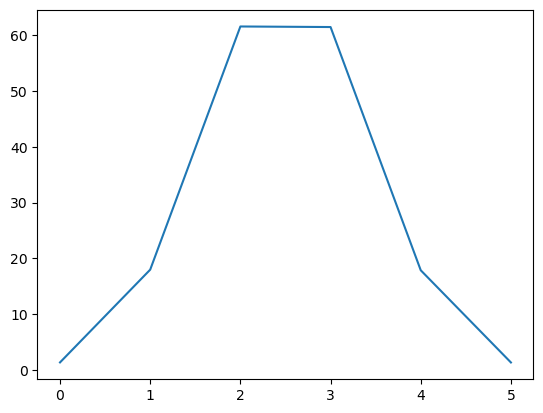

In [11]:
keffs =[]
for this in range(100):
  bank, kestimate = solver._solveST(bank=bank)
  keffs.append(kestimate)
print("keff average = " , np.mean(keffs), "+/-", np.std(keffs))
msh.plot_flux()


np.float64(0.03284260189144504)

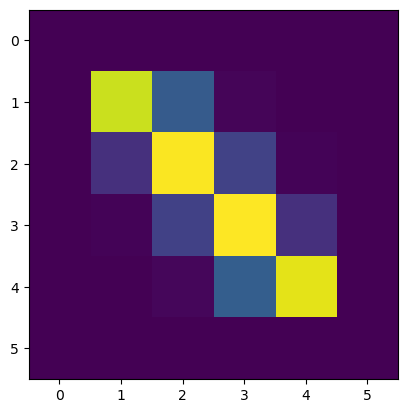

In [4]:
plt.imshow(msh.fma/100)

In [5]:
msh.fma

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 8.23022091e+01, 2.55000785e+01, 1.23400814e+00,
        1.21175710e-01, 0.00000000e+00],
       [0.00000000e+00, 1.24112537e+01, 8.88478611e+01, 1.75954956e+01,
        7.44077071e-01, 0.00000000e+00],
       [0.00000000e+00, 8.16547560e-01, 1.72206346e+01, 8.92991070e+01,
        1.22158697e+01, 0.00000000e+00],
       [0.00000000e+00, 2.94117647e-02, 1.39574444e+00, 2.67644671e+01,
        8.56771582e+01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]])

In [6]:
np.linalg.eig(msh.fma.transpose()/100)

EigResult(eigenvalues=array([1.1733683 , 0.95797321, 0.59751757, 0.73240427, 0.        ,
       0.        ]), eigenvectors=array([[ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-0.242309  ,  0.48479489, -0.3353614 , -0.55157443,  0.        ,
         0.        ],
       [-0.63888173,  0.55806598,  0.64969945,  0.36943425,  0.        ,
         0.        ],
       [-0.67570293, -0.45222085, -0.62356827,  0.52509712,  0.        ,
         0.        ],
       [-0.27666232, -0.49903165,  0.27674172, -0.53250071,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ]]))